# Lower-branch mass function (W51)

Estimates isochrone mass for every lower-branch source by dereddening it onto the **true, tabulated** 1 Myr PARSEC track (no linear approximation, no extrapolation past the track's mass range -- see `nirspec_mos_target_selection.ipynb` for the linear-approximation version used there for the NIRSpec $A_V$/branch bookkeeping), then builds the mass function for $M>10\,M_\odot$: differential ($dN/dM$, $dN/d\log M$) with power-law slope fits, and cumulative ($N(>M)$), which avoids the binning choice entirely and gives an independent slope estimate in both representations.

## Setup: imports, catalog photometry, isochrone, $A_V$, and the upper/lower branch split

In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import CT06_MWLoc
import warnings
warnings.filterwarnings('ignore')


In [2]:
def get_mag(catalog, ww, filtername='f162m'):
    flux = (catalog['flux_fit_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])
    if wav < 500:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    return vegamag

image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]
print(f'N sources in catalog: {len(catalog)}')

headers = {filt: fits.getheader(fn, ext=('SCI', 1)) for filt, fn in image_filenames.items()}
mags = {filt: get_mag(catalog, WCS(h), filtername=filt) for filt, h in headers.items()}

f162 = mags['f162m'].to_value(u.mag)
f210 = mags['f210m'].to_value(u.mag)
f360 = mags['f360m'].to_value(u.mag)
f480 = mags['f480m'].to_value(u.mag)


N sources in catalog: 15004


In [3]:
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']

# distance modulus for W51 (5.4 kpc)
dmod = 5 * np.log10(5400) - 5
F162Mmag_av0 = parsec_av0['col40'] + dmod
F210Mmag_av0 = parsec_av0['col42'] + dmod
F360Mmag_av0 = parsec_av0['col46'] + dmod
F480Mmag_av0 = parsec_av0['col50'] + dmod

age_idx = logage_av0 == 6  # 1 Myr

# linear-in-log-mass approximation, anchored at 0.1 and 20 Msun -- used only for the overall
# A_V estimate (get_av below) and the branch-split A_V threshold, NOT for the mass cut itself
MASS_LOW, MASS_HIGH = 0.1, 20
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_LOW))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_HIGH))

isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

print(f'isochrone anchors: {MASS_LOW} Msun -> (color={isochrone_x_start:.2f}, F162M={isochrone_y_start:.2f}), '
      f'{MASS_HIGH} Msun -> (color={isochrone_x_end:.2f}, F162M={isochrone_y_end:.2f})')


isochrone anchors: 0.1 Msun -> (color=0.20, F162M=18.86), 20 Msun -> (color=-0.11, F162M=10.77)


In [4]:
def get_av(color, mag, ext, isochrone_line_params, w_color=(1.62 * u.um, 2.10 * u.um), w_mag=1.62 * u.um):
    """A_V from the distance (along the CT06 MWLoc reddening vector) between (color, mag) and the isochrone line."""
    m_iso, b_iso = isochrone_line_params
    e_color_1 = ext(1 / w_color[0])
    e_color_2 = ext(1 / w_color[1])
    e_mag = ext(1 / w_mag)

    m_ext = e_mag / (e_color_1 - e_color_2)
    b_ext = mag - m_ext * color

    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    av = (mag - y_int) / e_mag
    return np.where(av < 0, 0, av)

ext = CT06_MWLoc()
av_estimate = get_av(f162 - f210, f162, ext=ext, isochrone_line_params=(color_slope, color_intercept))

# reddening vector per unit A_V in the (F162M-F210M, F162M) CMD -- reused throughout below
dcolor_per_av = ext(1 / 1.62 / u.um) - ext(1 / 2.10 / u.um)
dmag_per_av = ext(1 / 1.62 / u.um)


In [5]:
AV_MIN = 12  # same threshold used to define the lower/upper branch split

upper_idx = np.where((f360 - f480 > 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))
lower_idx = np.where((f360 - f480 <= 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))

print(f'N upper branch: {len(upper_idx[0])}, N lower branch: {len(lower_idx[0])}')


N upper branch: 1106, N lower branch: 2260


## Re-estimating isochrone mass for the lower branch, without the linear approximation

Every mass estimate in `nirspec_mos_target_selection.ipynb` (the $M>5\,M_\odot$ NIRSpec cut) went through a straight-line approximation of the isochrone. Here each lower-branch source is instead dereddened directly onto the **true, tabulated 1 Myr PARSEC track** (252 points, piecewise-linear between them, spanning 0.091-218.7 $M_\odot$):

For each source, and for every segment of the track, solve for the unique $(u, A_V)$ such that

$$\text{track}_i + u\,(\text{track}_{i+1}-\text{track}_i) + A_V\,(\Delta c_{A_V}, \Delta m_{A_V}) = (\text{color}_{\rm obs}, \text{mag}_{\rm obs})$$

i.e. reddening the point at fraction $u$ along segment $i$ by $A_V$ along the CT06 vector exactly reproduces the observed position. A segment is a valid solution only if $0\leq u\leq 1$ (the point falls strictly between two tabulated masses -- no extrapolation past the track's ends) and $A_V\geq 0$ (only real reddening, never de-reddening). Where a source's dereddening ray crosses more than one segment, the least-reddened ($A_V$-minimizing) solution is kept. Sources with **no** valid segment -- their dereddened position would fall beyond the lowest- or highest-mass tabulated point -- are discarded from the mass function rather than extrapolated.

In [6]:
# true isochrone track at 1 Myr, sorted by ascending mass
_track_order = np.argsort(np.asarray(mass_av0[age_idx]))
mass_track = np.asarray(mass_av0[age_idx])[_track_order]
color_track = np.asarray(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx])[_track_order]
mag_track = np.asarray(F162Mmag_av0[age_idx])[_track_order]
print(f'isochrone track: {len(mass_track)} points, mass range {mass_track.min():.3f}-{mass_track.max():.1f} Msun')


def deproject_isochrone_mass(color_obs, mag_obs, color_track, mag_track, mass_track,
                              dcolor_per_av, dmag_per_av):
    """Dereddens each (color_obs, mag_obs) onto the tabulated isochrone track by finding the
    least-reddened (A_V >= 0) point on the piecewise-linear track whose reddening vector passes
    through it. No extrapolation: sources whose dereddening ray never crosses the track between
    its lowest- and highest-mass points are left unmatched (mass = NaN).

    Returns
    -------
    mass : float ndarray -- isochrone mass at the matched track point (NaN if unmatched)
    av : float ndarray -- A_V of the matched point (NaN if unmatched)
    matched : bool ndarray -- True where a valid, non-extrapolated match was found
    """
    n = len(color_obs)
    best_mass = np.full(n, np.nan)
    best_av = np.full(n, np.inf)
    matched = np.zeros(n, dtype=bool)

    dx_track = np.diff(color_track)
    dy_track = np.diff(mag_track)

    for i in range(len(color_track) - 1):
        ax_, ay_ = dx_track[i], dy_track[i]
        det = ax_ * dmag_per_av - ay_ * dcolor_per_av
        if abs(det) < 1e-12:
            continue  # segment parallel to the reddening vector: no unique intersection
        rhs_x = color_obs - color_track[i]
        rhs_y = mag_obs - mag_track[i]
        u = (rhs_x * dmag_per_av - rhs_y * dcolor_per_av) / det
        s = (ax_ * rhs_y - ay_ * rhs_x) / det
        valid = (u >= 0) & (u <= 1) & (s >= 0) & np.isfinite(u) & np.isfinite(s)
        better = valid & (s < best_av)
        if not np.any(better):
            continue
        seg_mass = mass_track[i] + u * (mass_track[i + 1] - mass_track[i])
        best_mass[better] = seg_mass[better]
        best_av[better] = s[better]
        matched[better] = True

    best_av[~matched] = np.nan
    return best_mass, best_av, matched


lower_mask_all = np.zeros(f162.shape, dtype=bool)
lower_mask_all[lower_idx] = True

mass_iso_lower, av_iso_lower, matched_lower = deproject_isochrone_mass(
    (f162 - f210)[lower_mask_all], f162[lower_mask_all], color_track, mag_track, mass_track,
    dcolor_per_av, dmag_per_av)

print(f'N lower branch: {lower_mask_all.sum()}')
print(f'N matched to the isochrone track (kept): {matched_lower.sum()}')
print(f'N discarded (would require extrapolating past the track): {(~matched_lower).sum()}')
print(f'matched mass range: {np.nanmin(mass_iso_lower):.3f} - {np.nanmax(mass_iso_lower):.1f} Msun')


isochrone track: 252 points, mass range 0.091-218.7 Msun
N lower branch: 2260
N matched to the isochrone track (kept): 2199
N discarded (would require extrapolating past the track): 61
matched mass range: 0.092 - 191.0 Msun


## Mass function for $M > 10\,M_\odot$: $dN/dM$ and $dN/d\log M$, with power-law slope fits

Restricted to lower-branch sources with a valid (non-extrapolated) isochrone match, above $10\,M_\odot$. Both panels use the same log-spaced bins and Poisson ($\sqrt{N}$) error bars; each gets its own unweighted least-squares power-law fit in log-log space, $y \propto M^{\rm slope}$. By construction (equal-width bins in $\log M$), the two slopes should differ by almost exactly 1 ($dN/d\log M = M\ln10\,dN/dM$).

N sources with matched isochrone mass > 10 Msun: 170
dN/dM  slope (alpha, dN/dM ~ M^slope):      -2.12 +/- 0.20
dN/dlogM slope (Gamma, dN/dlogM ~ M^slope): -1.12 +/- 0.20
(difference should be ~1: 1.000)


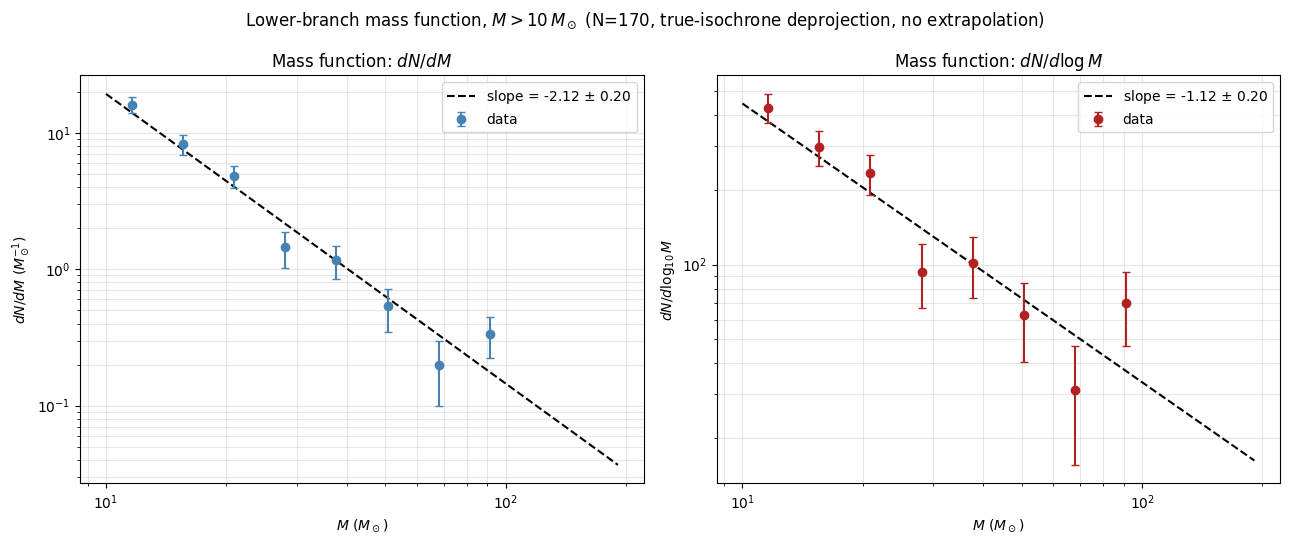

In [7]:
from scipy.stats import linregress


def fit_powerlaw_slope(x, y, yerr=None):
    """Unweighted least-squares power-law slope: log10(y) = slope*log10(x) + intercept.
    Returns (slope, slope_stderr, intercept)."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    result = linregress(np.log10(x[finite]), np.log10(y[finite]))
    return result.slope, result.stderr, result.intercept


mass_function_threshold = 10  # Msun

mf_mask = matched_lower & (mass_iso_lower > mass_function_threshold)
mf_mass = mass_iso_lower[mf_mask]
print(f'N sources with matched isochrone mass > {mass_function_threshold} Msun: {mf_mask.sum()}')

n_bins = 10
bin_edges = np.logspace(np.log10(mass_function_threshold), np.log10(mf_mass.max()), n_bins + 1)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # geometric mean, appropriate for log bins
counts, _ = np.histogram(mf_mass, bins=bin_edges)
counts_err = np.sqrt(counts)

dM = np.diff(bin_edges)
dlogM = np.diff(np.log10(bin_edges))

dN_dM = counts / dM
dN_dM_err = counts_err / dM
dN_dlogM = counts / dlogM
dN_dlogM_err = counts_err / dlogM

nonzero = counts > 0
slope_dNdM, slope_dNdM_err, intercept_dNdM = fit_powerlaw_slope(bin_centers[nonzero], dN_dM[nonzero])
slope_dNdlogM, slope_dNdlogM_err, intercept_dNdlogM = fit_powerlaw_slope(bin_centers[nonzero], dN_dlogM[nonzero])

print(f'dN/dM  slope (alpha, dN/dM ~ M^slope):      {slope_dNdM:.2f} +/- {slope_dNdM_err:.2f}')
print(f'dN/dlogM slope (Gamma, dN/dlogM ~ M^slope): {slope_dNdlogM:.2f} +/- {slope_dNdlogM_err:.2f}')
print(f'(difference should be ~1: {slope_dNdlogM - slope_dNdM:.3f})')

mfit_x = np.array([bin_edges[0], bin_edges[-1]])

fig, (axM, axlogM) = plt.subplots(1, 2, figsize=(13, 5.5))

axM.errorbar(bin_centers[nonzero], dN_dM[nonzero], yerr=dN_dM_err[nonzero], fmt='o', color='steelblue',
             capsize=3, zorder=3, label='data')
axM.plot(mfit_x, 10**intercept_dNdM * mfit_x**slope_dNdM, 'k--',
         label=f'slope = {slope_dNdM:.2f} $\pm$ {slope_dNdM_err:.2f}')
axM.set_xscale('log')
axM.set_yscale('log')
axM.set_xlabel(r'$M$ ($M_\odot$)')
axM.set_ylabel(r'$dN/dM$ ($M_\odot^{-1}$)')
axM.set_title(r'Mass function: $dN/dM$')
axM.legend(fontsize=10)
axM.grid(alpha=0.3, which='both')

axlogM.errorbar(bin_centers[nonzero], dN_dlogM[nonzero], yerr=dN_dlogM_err[nonzero], fmt='o', color='firebrick',
                 capsize=3, zorder=3, label='data')
axlogM.plot(mfit_x, 10**intercept_dNdlogM * mfit_x**slope_dNdlogM, 'k--',
            label=f'slope = {slope_dNdlogM:.2f} $\pm$ {slope_dNdlogM_err:.2f}')
axlogM.set_xscale('log')
axlogM.set_yscale('log')
axlogM.set_xlabel(r'$M$ ($M_\odot$)')
axlogM.set_ylabel(r'$dN/d\log_{10}M$')
axlogM.set_title(r'Mass function: $dN/d\log M$')
axlogM.legend(fontsize=10)
axlogM.grid(alpha=0.3, which='both')

fig.suptitle(f'Lower-branch mass function, $M>{mass_function_threshold}\,M_\odot$ '
             f'(N={mf_mask.sum()}, true-isochrone deprojection, no extrapolation)')
plt.tight_layout()
plt.savefig('lower_branch_mass_function.png', bbox_inches='tight')
plt.show()


## Cumulative mass function: a binning-free slope estimate

$N(>M)$, the number of sources more massive than $M$, needs no bin choice at all -- every source contributes its own step. For a power-law $dN/dM \propto M^{-\alpha}$, $N(>M) \propto M^{1-\alpha} = M^{-\Gamma}$ (using $\Gamma=\alpha-1$, the $dN/d\log M$ index), so a single log-log fit to $N(>M)$ gives the power-law index in *both* representations at once: the fitted slope directly **is** the $dN/d\log M$ index $-\Gamma$, and the $dN/dM$ index is that slope minus 1.

cumulative N(>M) slope:                     -1.51 +/- 0.02
  -> implied dN/dlogM slope (Gamma):         -1.51 +/- 0.02
  -> implied dN/dM slope (alpha):            -2.51 +/- 0.02
(binned fits for comparison: dN/dM=-2.12+/-0.20, dN/dlogM=-1.12+/-0.20)


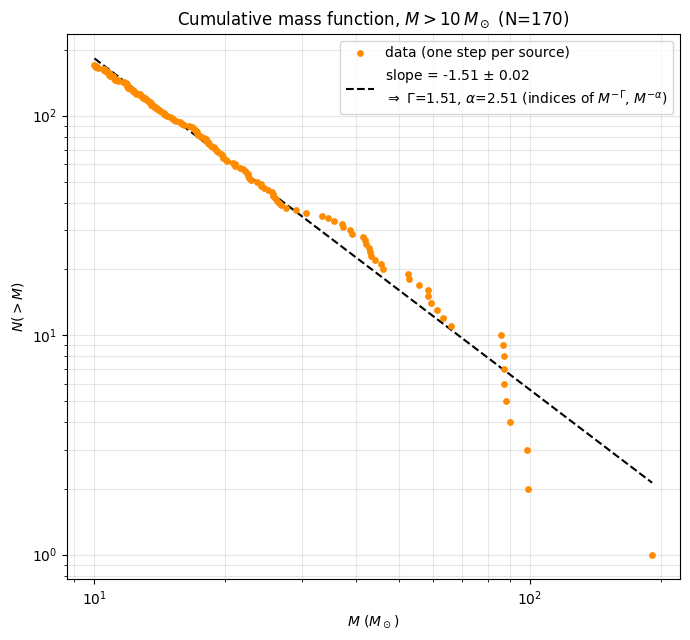

In [8]:
mass_sorted = np.sort(mf_mass)[::-1]  # descending
N_above = np.arange(1, len(mass_sorted) + 1)  # N(>=mass_sorted[i])

slope_cum, slope_cum_err, intercept_cum = fit_powerlaw_slope(mass_sorted, N_above)
slope_cum_dNdlogM = slope_cum        # N(>M) ~ M^slope_cum is the same power law as dN/dlogM
slope_cum_dNdM = slope_cum - 1       # dN/dM index is one less

print(f'cumulative N(>M) slope:                     {slope_cum:.2f} +/- {slope_cum_err:.2f}')
print(f'  -> implied dN/dlogM slope (Gamma):         {slope_cum_dNdlogM:.2f} +/- {slope_cum_err:.2f}')
print(f'  -> implied dN/dM slope (alpha):            {slope_cum_dNdM:.2f} +/- {slope_cum_err:.2f}')
print(f'(binned fits for comparison: dN/dM={slope_dNdM:.2f}+/-{slope_dNdM_err:.2f}, '
      f'dN/dlogM={slope_dNdlogM:.2f}+/-{slope_dNdlogM_err:.2f})')

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(mass_sorted, N_above, s=15, color='darkorange', zorder=3, label='data (one step per source)')
cfit_x = np.array([mass_sorted.min(), mass_sorted.max()])
ax.plot(cfit_x, 10**intercept_cum * cfit_x**slope_cum, 'k--',
        label=(f'slope = {slope_cum:.2f} $\pm$ {slope_cum_err:.2f}\n'
               f'$\Rightarrow\ \Gamma$={-slope_cum_dNdlogM:.2f}, '
               f'$\\alpha$={-slope_cum_dNdM:.2f} (indices of $M^{{-\Gamma}}$, $M^{{-\\alpha}}$)'))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M$ ($M_\odot$)')
ax.set_ylabel(r'$N(>M)$')
ax.set_title(f'Cumulative mass function, $M>{mass_function_threshold}\,M_\odot$ (N={mf_mask.sum()})')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lower_branch_mass_function_cumulative.png', bbox_inches='tight')
plt.show()


### Sanity check: the $M>10\,M_\odot$ selection on the CMD

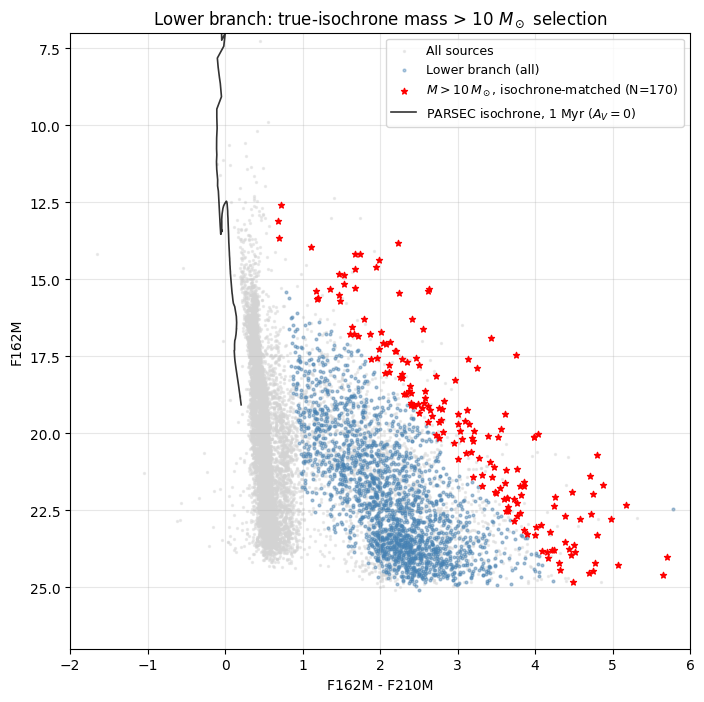

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.4, label='All sources')
ax.scatter((f162 - f210)[lower_mask_all], f162[lower_mask_all], s=4, c='steelblue', alpha=0.4,
           label='Lower branch (all)')
lower_indices = np.where(lower_mask_all)[0]
mf_indices = lower_indices[mf_mask]
ax.scatter((f162 - f210)[mf_indices], f162[mf_indices], s=20, c='red', marker='*', zorder=4,
           label=f'$M>{mass_function_threshold}\,M_\odot$, isochrone-matched (N={mf_mask.sum()})')
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('Lower branch: true-isochrone mass > 10 $M_\odot$ selection')
plt.savefig('lower_branch_mass_function_cmd_check.png', bbox_inches='tight')
plt.show()


## The low-mass end of the lower branch: bare stars, or something else?

The lower branch is defined by *color*, not by local environment -- nothing so far has looked at whether a source actually sits in dense natal gas. Reusing the method from `color_magnitude_diagram_cleancat.ipynb` (`co_plank`, despite its name and filename, is confirmed there to be the ATLASGAL 870 $\mu$m continuum map reprojected onto the F480M grid, in Jy/beam; nearest-pixel lookup via `ix`/`iy`), we flag lower-branch sources sitting on **low 870 $\mu$m continuum** -- i.e. not currently embedded in a dense gas clump -- and show the CMD with those sources removed, to see whether they matter for the shape of the low-mass end.

N lower branch: 2260
N lower branch with 870um continuum < 1.5 Jy/beam (low-density environment): 811


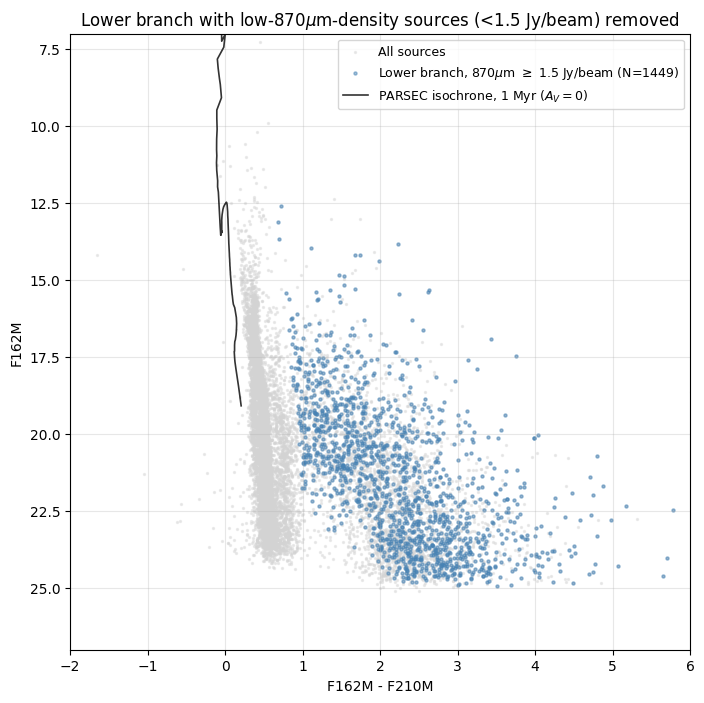

In [10]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm

wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
pixcoord_ref = wcs_f480m.all_world2pix(catalog['skycoord_ref'].ra.deg, catalog['skycoord_ref'].dec.deg, 0)

# despite the variable name, this is the ATLASGAL 870um continuum map (Jy/beam), reprojected
# onto the F480M pixel grid -- see the note in color_magnitude_diagram_cleancat.ipynb
co_planck_fn = '/orange/adamginsburg/jwst/w51/data_reprojected_480/co_planck_reprojected_to_f480m.fits'
co_plank = fits.getdata(co_planck_fn, ext=0)

ix = np.clip(np.round(pixcoord_ref[0]).astype(int), 0, co_plank.shape[1] - 1)
iy = np.clip(np.round(pixcoord_ref[1]).astype(int), 0, co_plank.shape[0] - 1)
co_plank_at_source = co_plank[iy, ix]

flux_870_threshold = 1.5  # Jy/beam -- try 1.0 for the stricter cut used in the reference notebook
low_870_mask_lower = (co_plank_at_source[lower_mask_all] < flux_870_threshold)
print(f'N lower branch: {lower_mask_all.sum()}')
print(f'N lower branch with 870um continuum < {flux_870_threshold} Jy/beam (low-density environment): '
      f'{low_870_mask_lower.sum()}')

color_lower_all = (f162 - f210)[lower_mask_all]
mag_lower_all = f162[lower_mask_all]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.4, label='All sources')
ax.scatter(color_lower_all[~low_870_mask_lower], mag_lower_all[~low_870_mask_lower], s=5, c='steelblue',
           alpha=0.5, label=f'Lower branch, 870$\mu$m $\geq$ {flux_870_threshold} Jy/beam '
                             f'(N={(~low_870_mask_lower).sum()})')
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title(f'Lower branch with low-870$\mu$m-density sources (<{flux_870_threshold} Jy/beam) removed')
plt.savefig('lower_branch_cmd_no_low_870um.png', bbox_inches='tight')
plt.show()


## CMD color-coded by isochrone mass, with the isochrone's degenerate "hook" masked out

The 1 Myr PARSEC track is not monotonic in the direction perpendicular to reddening (the coordinate that actually determines the dereddened match): it briefly folds back on itself around a few $M_\odot$ (the well-known PMS "hook" near the radiative-convective transition). Detected directly from the tabulated track below (a sign change in $t=\mathrm{color}\cdot\Delta m_{A_V} - \mathrm{mag}\cdot\Delta c_{A_V}$, the reddening-invariant coordinate, restricted to a plausible hook mass window so sparse-grid noise elsewhere isn't mistaken for a fold) -- inside that range a single dereddened position can correspond to more than one true mass.

The degenerate sources have to be identified by each source's own $t$ value falling in the range the hook spans, not by the mass `deproject_isochrone_mass` happened to assign: its least-reddened tie-break systematically routes degenerate sources onto the non-hook part of the track (checked directly: masking on assigned mass alone catches 0 sources, vs. well over a hundred using $t$).

Isochrone hook (non-monotonic in the dereddened coordinate): 4.08 - 5.14 Msun
N lower branch matched to the isochrone: 2199
N in the degenerate hook range (left uncolored): 160
N safely color-coded by mass: 2039


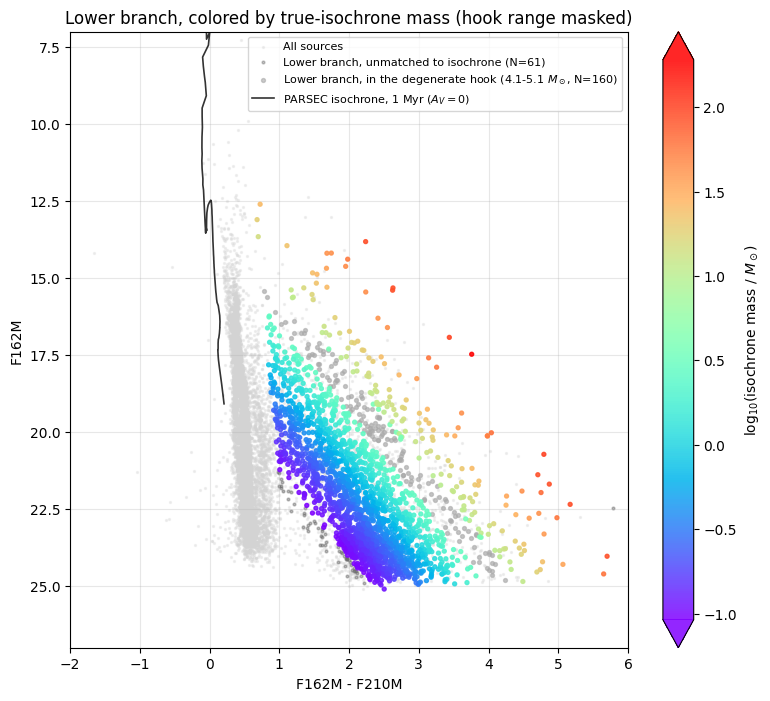

In [11]:
t_track = color_track * dmag_per_av - mag_track * dcolor_per_av

# restrict the search to a plausible PMS-hook mass window, so unrelated sparse-grid steps
# at the very low- or very high-mass ends of the track aren't mistaken for a real fold
hook_search = (mass_track > 2) & (mass_track < 15)
dt = np.diff(t_track)
dt_search = hook_search[:-1] & hook_search[1:]
significant = (np.abs(dt) > 0.001) & dt_search
sign = np.where(significant, np.sign(dt), 0)
nz_mask = sign != 0
turn_idx = np.where(nz_mask)[0][1:][np.diff(sign[nz_mask]) != 0]

hook_mass_min, hook_mass_max = mass_track[turn_idx].min(), mass_track[turn_idx].max()
in_hook_mass = (mass_track >= hook_mass_min) & (mass_track <= hook_mass_max)
t_hook_min, t_hook_max = t_track[in_hook_mass].min(), t_track[in_hook_mass].max()
print(f'Isochrone hook (non-monotonic in the dereddened coordinate): '
      f'{hook_mass_min:.2f} - {hook_mass_max:.2f} Msun')

# mask by each source's OWN (reddening-invariant) t coordinate falling in the hook's t-range,
# not by the mass the deprojection happened to assign: the least-reddened tie-break in
# deproject_isochrone_mass systematically routes degenerate sources onto the non-hook part of
# the track, so masking on the assigned mass alone misses essentially all of them (checked:
# 0 sources land in the hook mass range this way, vs the count below using t directly)
t_obs_lower = color_lower_all * dmag_per_av - mag_lower_all * dcolor_per_av
in_hook = matched_lower & (t_obs_lower >= t_hook_min) & (t_obs_lower <= t_hook_max)
colorable = matched_lower & ~in_hook
print(f'N lower branch matched to the isochrone: {matched_lower.sum()}')
print(f'N in the degenerate hook range (left uncolored): {in_hook.sum()}')
print(f'N safely color-coded by mass: {colorable.sum()}')

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.3, label='All sources')
ax.scatter(color_lower_all[~matched_lower], mag_lower_all[~matched_lower], s=4, c='dimgray', alpha=0.4,
           label=f'Lower branch, unmatched to isochrone (N={(~matched_lower).sum()})')
ax.scatter(color_lower_all[in_hook], mag_lower_all[in_hook], s=8, c='darkgray', alpha=0.6,
           label=f'Lower branch, in the degenerate hook ({hook_mass_min:.1f}-{hook_mass_max:.1f} '
                 f'$M_\odot$, N={in_hook.sum()})')
im = ax.scatter(color_lower_all[colorable], mag_lower_all[colorable], s=8,
                 c=np.log10(mass_iso_lower[colorable]), cmap='rainbow', alpha=0.85, zorder=4)
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
cbar = plt.colorbar(im, ax=ax, extend='both')
cbar.set_label(r'log$_{10}$(isochrone mass / $M_\odot$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('Lower branch, colored by true-isochrone mass (hook range masked)')
plt.savefig('lower_branch_cmd_colored_by_mass_hook_masked.png', bbox_inches='tight')
plt.show()


## What are the low-mass, low-870$\mu$m-density lower-branch sources?

Removing the sources with little 870 $\mu$m continuum at their position (above) barely touches the shape of the low-mass end of the lower branch, so this population isn't just an artifact of dense-clump-projected photometry: most low-mass lower-branch sources already sit where there isn't much dense gas *in projection*. A few points worth separating, since "low 870 $\mu$m flux at the source position" and "no circumstellar dust" are not the same claim:

- **A_V here is a line-of-sight quantity, not a local-environment one.** The branch definition requires $A_V>12$ from `get_av`, which reddens the source itself; the 870 $\mu$m flux measures dense gas *projected at that sky position*, which need not be physically associated with the star (foreground/background diffuse ISM along the sightline reddens just as well as a natal envelope does). A source can be genuinely embedded in a natal core with A_V well above 12 *and* still sit in a 870 $\mu$m-faint pixel, if the emitting dust is warm/compact and the single-dish 870 $\mu$m beam (21$''$, coarse next to NIRCam's resolution) simply doesn't resolve or centroid on it -- so this cut is at best a coarse, projected proxy for "not in a dense clump," not proof of "dust-free."
- **This NIR/MIR color selection is only sensitive to warm inner-disk dust.** F360M/F480M excess (what separates the branches to begin with) traces hot dust close to the star. A star that has cleared its *inner* disk (a transition disk) while retaining a cooler outer disk, or one whose disk is simply faint relative to this survey's depth, would show no excess here without being genuinely diskless.
- **Malmquist-type bias favors exactly this appearance.** At $\lesssim1$ Myr, low-mass PMS stars are intrinsically faint and still contracting; a deeply embedded, dusty low-mass source is preferentially *not* detected (or scattered into the upper branch / missing-NIR "very red" category) rather than appearing here as a clean, low-extinction point. The detected low-mass lower-branch population is thus the least-embedded tail of the true low-mass population by construction, not a random sample of it.
- **Line-of-sight contamination is a real alternative.** A $A_V>12$, no-excess source could simply be a reddened field star (foreground disk population, or something well behind W51) with nothing to do with the protocluster's current star formation -- reddened by diffuse foreground ISM rather than a natal envelope, which would trivially explain the absence of any disk signature.

On the specific expectation -- yes, disk fractions in young ($\lesssim1$-2 Myr) clusters are typically still high (order 50-80% in well-studied nearby regions), so *most* genuine low-mass members this young should show some IR excess. But that fraction is not 100% even at these ages (fast disk dissipation, dynamical truncation in a crowded cluster, or photoevaporation near the OB stars powering W51 can all clear inner disks early), and every effect above works in the direction of making already-diskless-*looking* sources over-represented in this particular selection. So the honest read is that this subsample is probably a mix -- some genuinely early diskless/transition-disk objects, plus a real contribution from line-of-sight contaminants and survey-depth/geometry bias -- rather than being cleanly explained by any one of these on its own.

## Spatial distribution of the $M>10\,M_\odot$ lower-branch sources, and left vs. right half of the field

The $M>10\,M_\odot$ isochrone-matched lower-branch sources (the same sample as the mass function above) plotted on the F480M image, in the image's own pixel frame (the mosaic is rotated relative to north-up, so "left"/"right" here means the image's $x$ axis, not east/west). The field is split at the midpoint of the image's $x$ axis, and the cumulative isochrone-mass distribution is compared between the two halves, both as absolute counts $N(>M)$ (with the same log-log slope fit as above) and as a normalized distribution with a two-sample Kolmogorov-Smirnov test.

image x midpoint: 2822.5 px
N(M>10 Msun) left half: 93, right half: 77
median mass  left: 16.9 Msun, right: 17.5 Msun


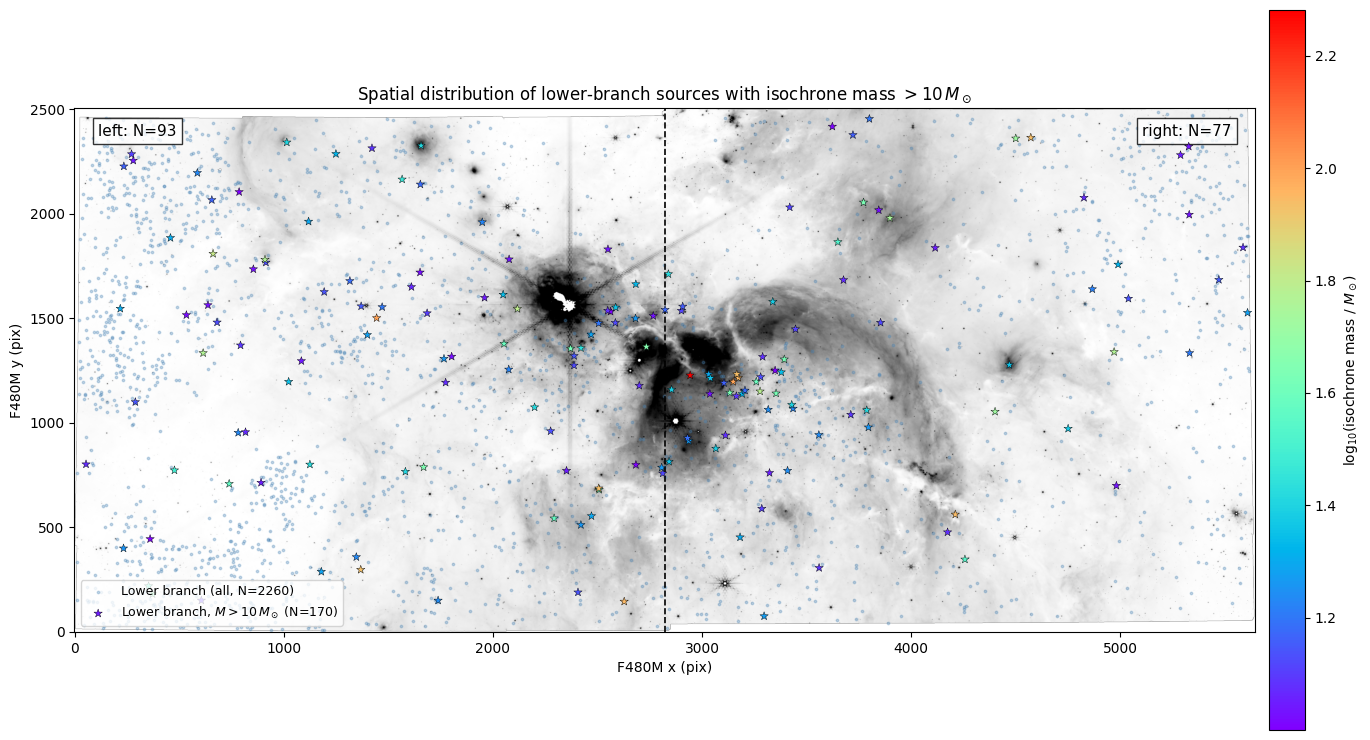

two-sample KS test: D = 0.092, p = 0.826
left  half: N=93, cumulative N(>M) slope = -1.57 +/- 0.02
right half: N=77, cumulative N(>M) slope = -1.37 +/- 0.02


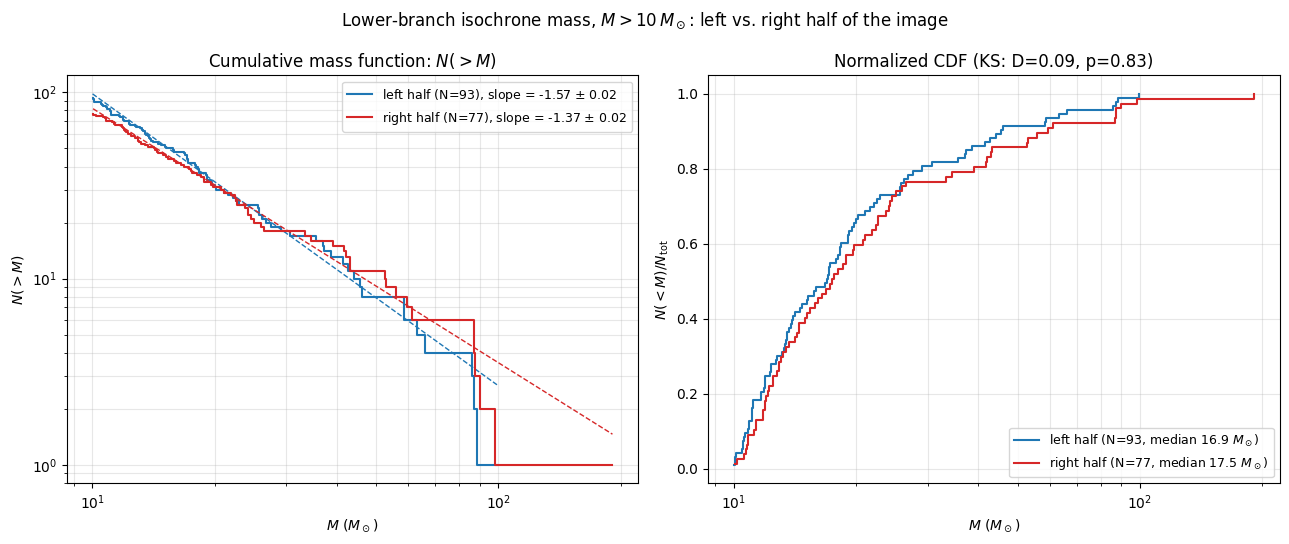

In [12]:
from scipy.stats import ks_2samp

x_mid = f480m_data.shape[1] / 2  # midpoint of the image x axis (F480M pixel frame)

px_lower = pixcoord_ref[0][lower_mask_all]
py_lower = pixcoord_ref[1][lower_mask_all]
px_mf, py_mf = px_lower[mf_mask], py_lower[mf_mask]
left_mf = px_mf < x_mid
right_mf = ~left_mf
mass_left = mf_mass[left_mf]
mass_right = mf_mass[right_mf]
print(f'image x midpoint: {x_mid:.1f} px')
print(f'N(M>{mass_function_threshold} Msun) left half: {left_mf.sum()}, right half: {right_mf.sum()}')
print(f'median mass  left: {np.median(mass_left):.1f} Msun, right: {np.median(mass_right):.1f} Msun')

# --- spatial map ---
fig, ax = plt.subplots(figsize=(15, 7.5))
norm_img = simple_norm(f480m_data, 'asinh', min_percent=1, max_percent=99.5)
ax.imshow(f480m_data, origin='lower', cmap='gray_r', norm=norm_img)
ax.scatter(px_lower, py_lower, s=3, c='steelblue', alpha=0.3,
           label=f'Lower branch (all, N={lower_mask_all.sum()})')
im = ax.scatter(px_mf, py_mf, s=40, c=np.log10(mf_mass), cmap='rainbow', marker='*',
                edgecolor='k', linewidth=0.3, zorder=4,
                label=f'Lower branch, $M>{mass_function_threshold}\,M_\odot$ (N={mf_mask.sum()})')
ax.axvline(x_mid, color='k', ls='--', lw=1.2)
ax.text(0.02, 0.97, f'left: N={left_mf.sum()}', transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8))
ax.text(0.98, 0.97, f'right: N={right_mf.sum()}', transform=ax.transAxes, va='top', ha='right',
        fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label(r'log$_{10}$(isochrone mass / $M_\odot$)')
ax.set_xlabel('F480M x (pix)')
ax.set_ylabel('F480M y (pix)')
ax.set_title(f'Spatial distribution of lower-branch sources with isochrone mass $>{mass_function_threshold}\,M_\odot$')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig('lower_branch_m10_spatial_map.png', bbox_inches='tight')
plt.show()

# --- cumulative distributions, left vs right ---
ks = ks_2samp(mass_left, mass_right)
print(f'two-sample KS test: D = {ks.statistic:.3f}, p = {ks.pvalue:.3g}')

fig, (axN, axF) = plt.subplots(1, 2, figsize=(13, 5.5))
for m_half, name, color in [(mass_left, 'left', 'tab:blue'), (mass_right, 'right', 'tab:red')]:
    m_desc = np.sort(m_half)[::-1]
    n_above = np.arange(1, len(m_desc) + 1)
    s_half, s_half_err, b_half = fit_powerlaw_slope(m_desc, n_above)
    print(f'{name:5s} half: N={len(m_desc)}, cumulative N(>M) slope = {s_half:.2f} +/- {s_half_err:.2f}')
    axN.step(m_desc, n_above, where='post', color=color, lw=1.5,
             label=f'{name} half (N={len(m_desc)}), slope = {s_half:.2f} $\pm$ {s_half_err:.2f}')
    xfit = np.array([m_desc.min(), m_desc.max()])
    axN.plot(xfit, 10**b_half * xfit**s_half, '--', color=color, lw=1)

    m_asc = np.sort(m_half)
    axF.step(m_asc, np.arange(1, len(m_asc) + 1) / len(m_asc), where='post', color=color, lw=1.5,
             label=f'{name} half (N={len(m_asc)}, median {np.median(m_asc):.1f} $M_\odot$)')

axN.set_xscale('log')
axN.set_yscale('log')
axN.set_xlabel(r'$M$ ($M_\odot$)')
axN.set_ylabel(r'$N(>M)$')
axN.set_title(r'Cumulative mass function: $N(>M)$')
axN.legend(fontsize=9)
axN.grid(alpha=0.3, which='both')

axF.set_xscale('log')
axF.set_xlabel(r'$M$ ($M_\odot$)')
axF.set_ylabel(r'$N(<M)/N_{\rm tot}$')
axF.set_title(f'Normalized CDF (KS: D={ks.statistic:.2f}, p={ks.pvalue:.2g})')
axF.legend(fontsize=9, loc='lower right')
axF.grid(alpha=0.3, which='both')

fig.suptitle(f'Lower-branch isochrone mass, $M>{mass_function_threshold}\,M_\odot$: left vs. right half of the image')
plt.tight_layout()
plt.savefig('lower_branch_m10_cumulative_left_right.png', bbox_inches='tight')
plt.show()